In [1]:
%cd ../..

/home/eli/AnacondaProjects/epych


In [2]:
%env DASK_LOGGING__DISTRIBUTED=CRITICAL
%env OMPI_MCA_btl_sm_backing_directory=/mnt/data/tmp_storage
%env SPYTMPDIR=/mnt/data/tmp_storage
%env SPYLOGLEVEL=CRITICAL
%env SPYPARLOGLEVEL=CRITICAL

env: DASK_LOGGING__DISTRIBUTED=CRITICAL
env: OMPI_MCA_btl_sm_backing_directory=/mnt/data/tmp_storage
env: SPYTMPDIR=/mnt/data/tmp_storage
env: SPYLOGLEVEL=CRITICAL
env: SPYPARLOGLEVEL=CRITICAL


In [3]:
import collections
import functools
import logging
import numpy as np
import os
import quantities as pq

import epych
from epych.statistics import alignment, spectrum

[striatum:1843160] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.striatum.1000/jf.0/3923312640/shared_mem_cuda_pool.striatum could be created.
[striatum:1843160] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


In [4]:
%matplotlib inline

In [5]:
logging.basicConfig(level=logging.INFO)

In [6]:
ADAPTED_ONSET = pq.Quantity(-1.0) * pq.second
ADAPTED_OFFSET = pq.Quantity(-0.5) * pq.second
ODDBALL_ONSET = pq.Quantity(-1.9017372477960602e-14) * pq.second
ODDBALL_OFFSET = pq.Quantity(0.5004545430388676) * pq.second
EVENTS = {
    "Oddball": (ODDBALL_ONSET.magnitude, 'lightgreen'),
    "Offset": (ODDBALL_OFFSET.magnitude, 'red'),
}
FREQ_RANGE = (spectrum.THETA_BAND[0].magnitude, spectrum.GAMMA_BAND[1].magnitude)

In [7]:
CONDITIONS = ["lonaive", "go_gloexp", "go_seqctl", "lo_gloexp", "lo_rndctl", "igo_seqctl"]
CONDITION_TITLES = {
    "lonaive": "Habituation",
    "go_gloexp": "xxxX [B1]",
    "go_seqctl": "xxxx [B3]",
    "lo_gloexp": "xxxY [B1]",
    "lo_rndctl": "XXXY [B2]",
    "igo_seqctl": "yyyy [B3]"
}
CONTRAST_VLIMS = {
    "dd": 9.,
    "go": 5.,
    "ssa": 10.,
}
CONDITION_VLIMS = {
    "lonaive": CONTRAST_VLIMS["dd"],
    "go_gloexp": CONTRAST_VLIMS["go"],
    "go_seqctl": CONTRAST_VLIMS["go"],
    "lo_gloexp": CONTRAST_VLIMS["ssa"],
    "lo_rndctl": CONTRAST_VLIMS["dd"],
    "igo_seqctl": CONTRAST_VLIMS["ssa"]
}

In [8]:
area_titles = {
    "VISal": "AL",
    "VISam": "AM",
    "VISl": "LM",
    "VISp": "V1",
    "VISpm": "PM",
    "VISrl": "RL",
}
def stattitle(name, stat):
    if name in area_titles:
        return area_titles[name]
    return name
anatomical_areas = ['VISp', 'VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']

In [9]:
def condition_stattitle(cond, name, stat, layer=None):
    suffix = " (%s, %s)" % (CONDITION_TITLES[cond], layer) if layer else " (%s)" % CONDITION_TITLES[cond]
    return stattitle(name, stat) + suffix

In [10]:
def initialize_spectrum(key, signal, path=None):
    area = os.path.commonprefix([loc for loc in signal.channels.location])
    return epych.statistics.spectrum.Spectrogram(signal.df, signal.channels, signal.f0, taper="hann", path=path + "/" + key, time_window=0.200)

In [11]:
summaries = {}
tfr_summaries = {}

In [12]:
for cond in CONDITIONS:
    cond_path = "/mnt/data/000253/grand_spectrogram_downsample4_%s" % cond
    summaries[cond] = epych.statistic.Summary.unpickle(cond_path, epych.statistics.spectrum.Spectrogram)
    logging.info("Loaded LFP spectrograms across condition %s" % cond)

INFO:root:Loaded LFP spectrograms across condition lonaive
INFO:root:Loaded LFP spectrograms across condition go_gloexp
INFO:root:Loaded LFP spectrograms across condition go_seqctl
INFO:root:Loaded LFP spectrograms across condition lo_gloexp
INFO:root:Loaded LFP spectrograms across condition lo_rndctl
INFO:root:Loaded LFP spectrograms across condition igo_seqctl


In [13]:
for cond in CONDITIONS:
    tfr_summaries[cond] = summaries[cond].results().smap(lambda sig: sig.oscillatory().select_freqs(*FREQ_RANGE)).erp()
    tfr_summaries[cond] = tfr_summaries[cond].smap(lambda tfr: tfr.baseline(-1.350 * pq.second, -1.010 * pq.second, decibels=True))
    logging.info("Calculated evoked spectrograms across condition %s" % cond)

INFO:root:Calculated evoked spectrograms across condition lonaive
INFO:root:Calculated evoked spectrograms across condition go_gloexp
INFO:root:Calculated evoked spectrograms across condition go_seqctl
INFO:root:Calculated evoked spectrograms across condition lo_gloexp
INFO:root:Calculated evoked spectrograms across condition lo_rndctl
INFO:root:Calculated evoked spectrograms across condition igo_seqctl


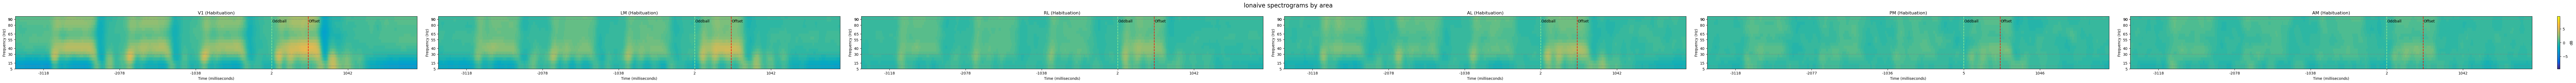

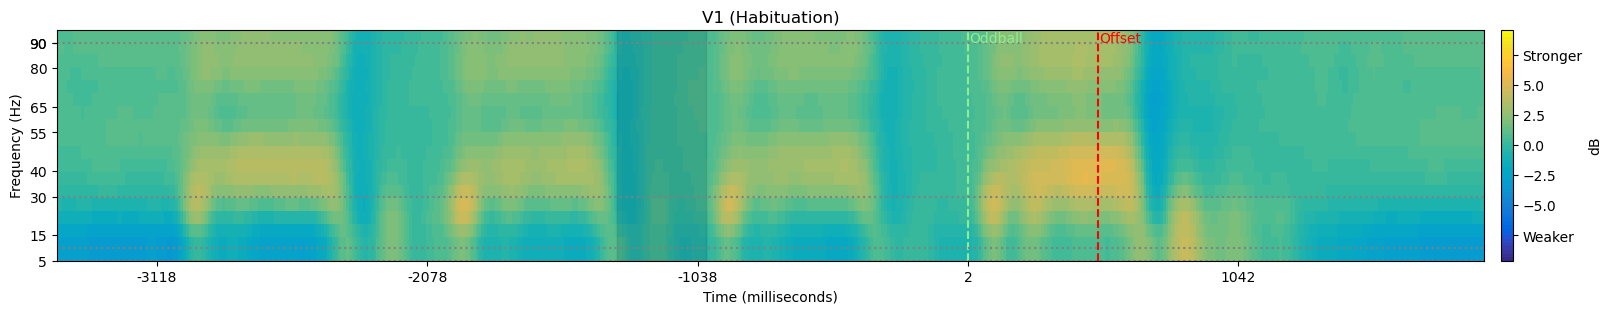

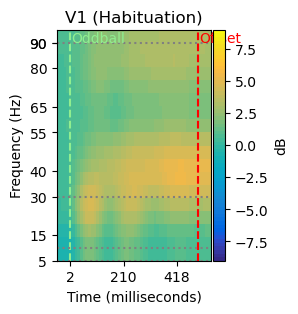

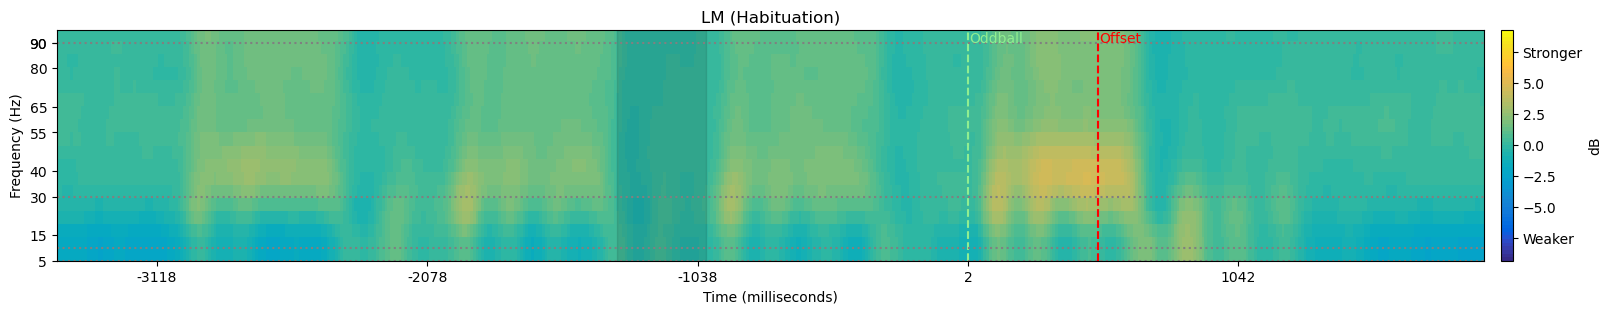

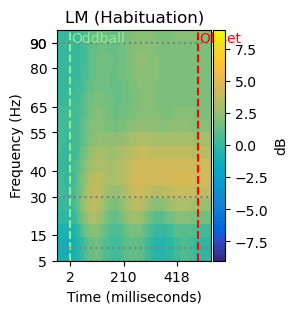

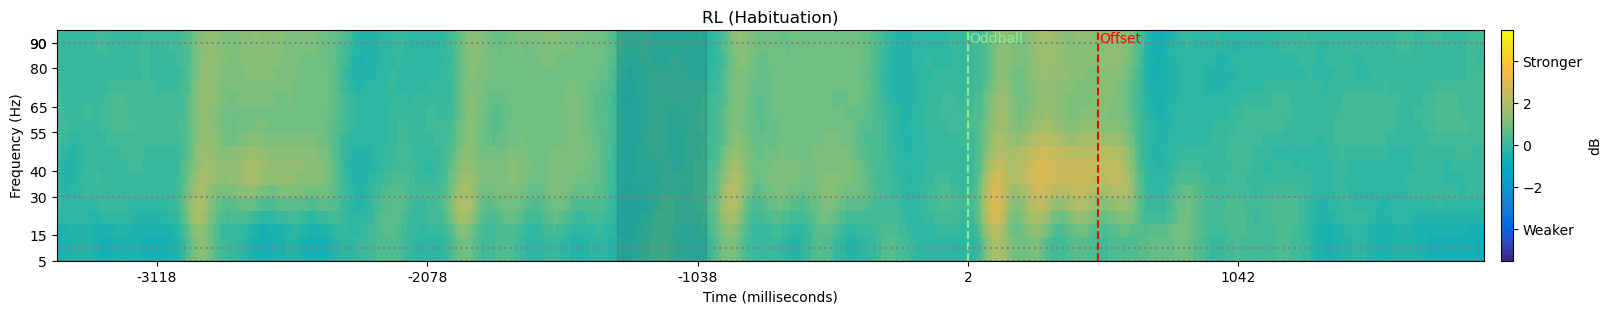

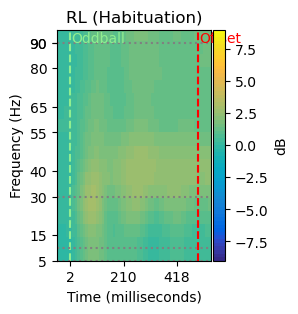

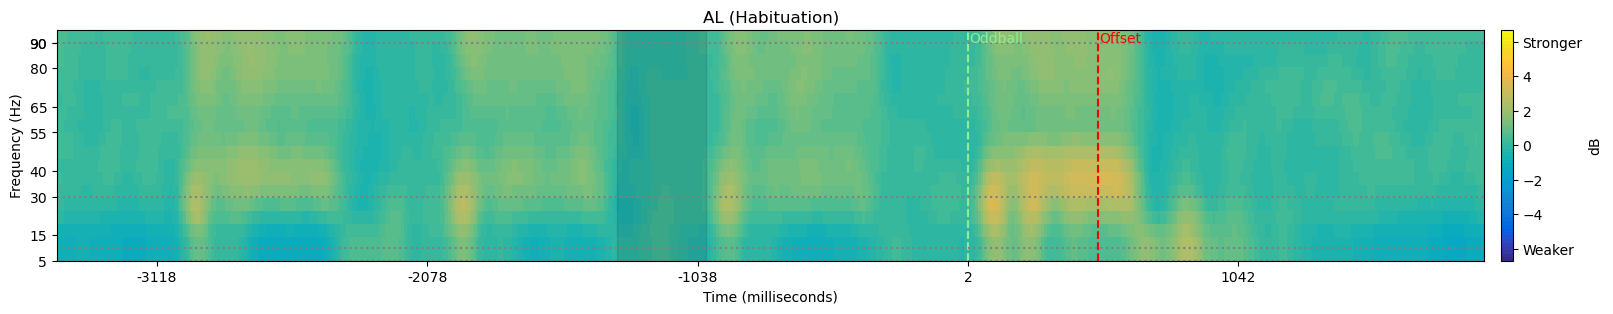

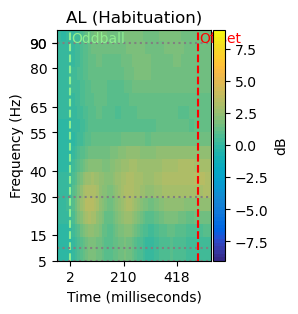

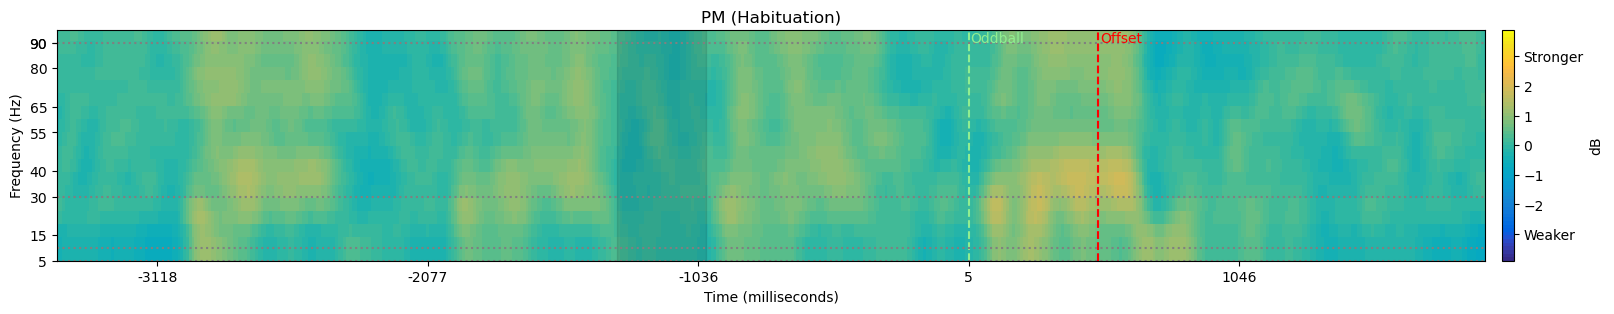

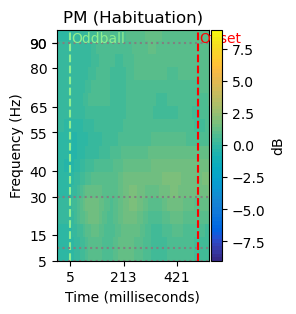

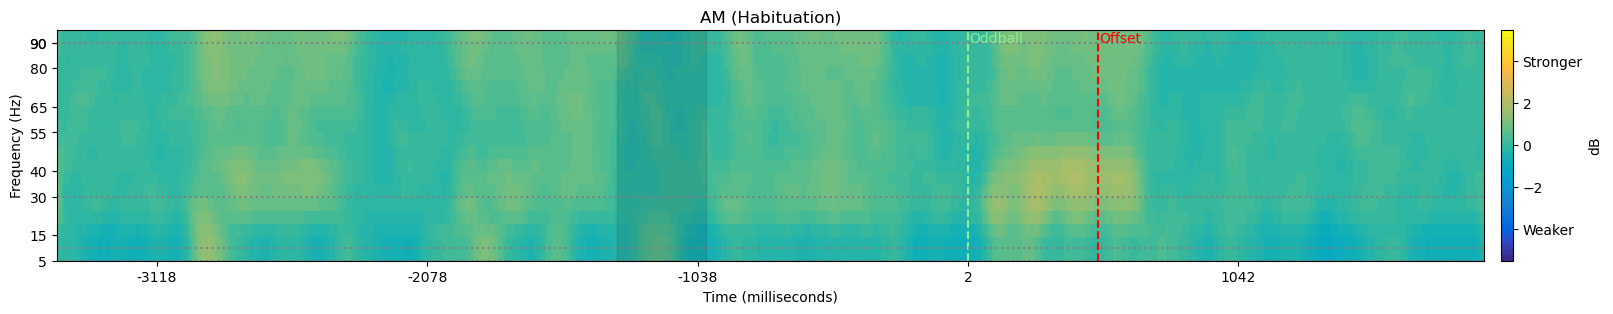

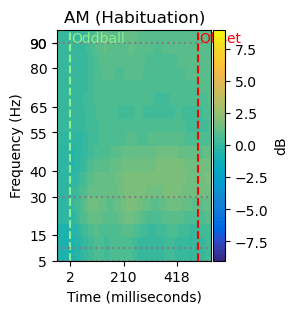

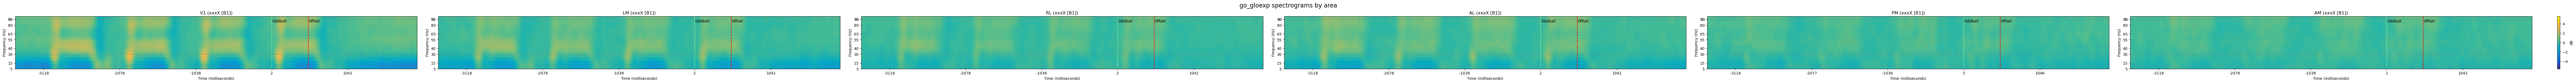

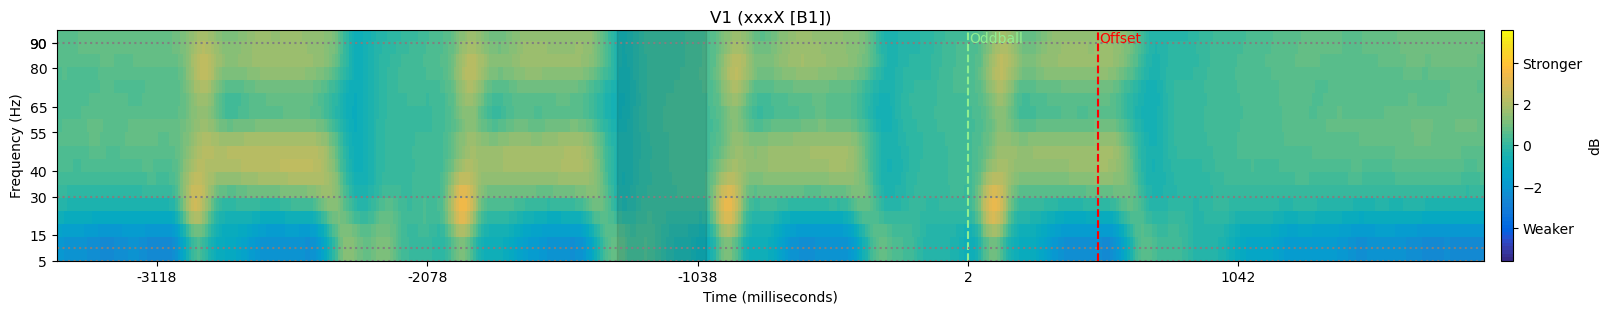

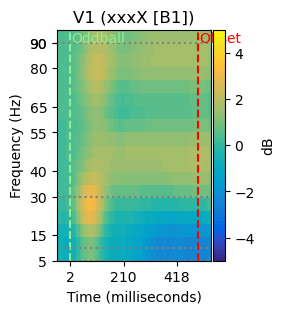

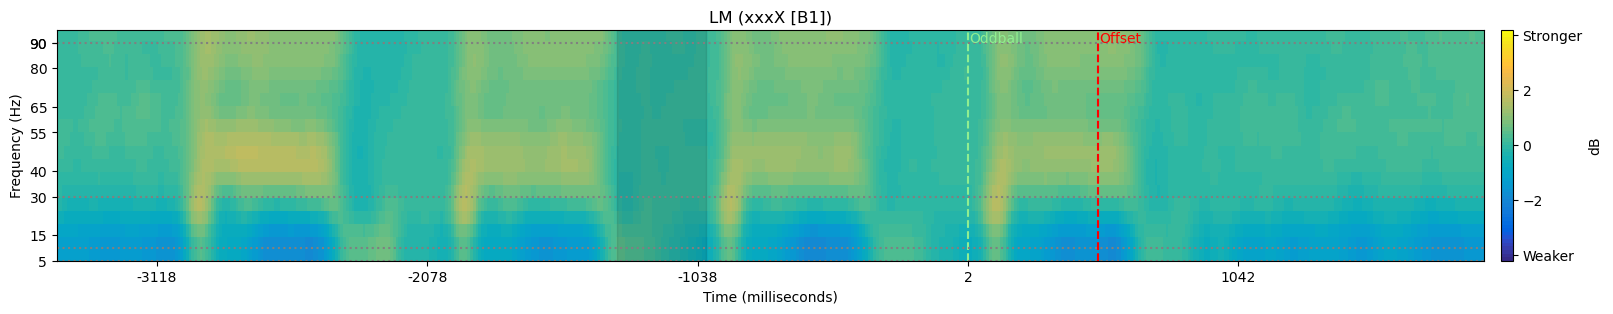

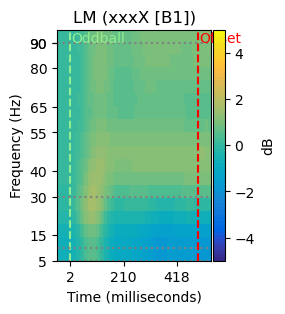

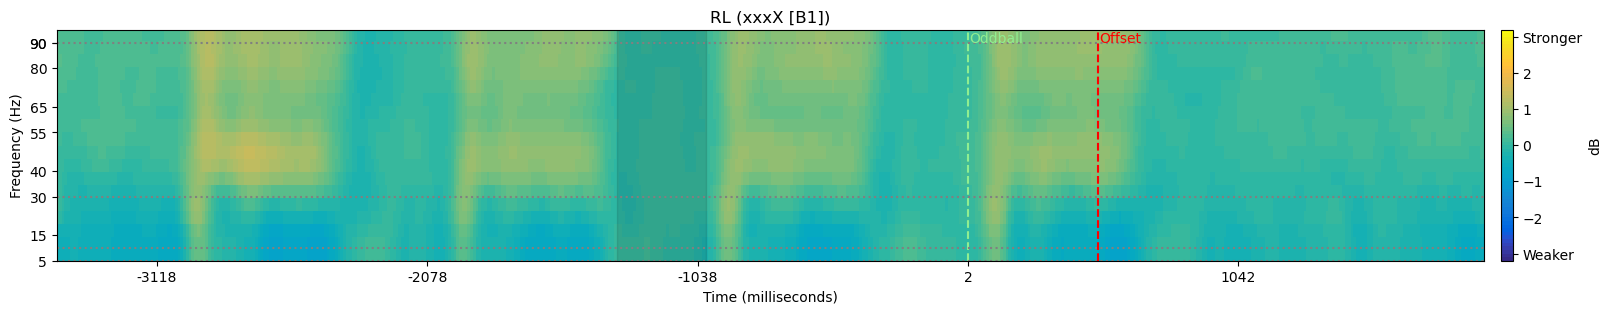

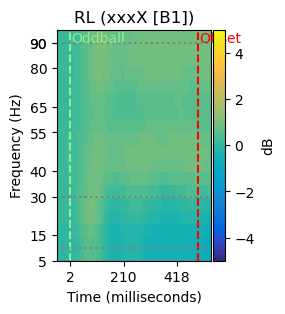

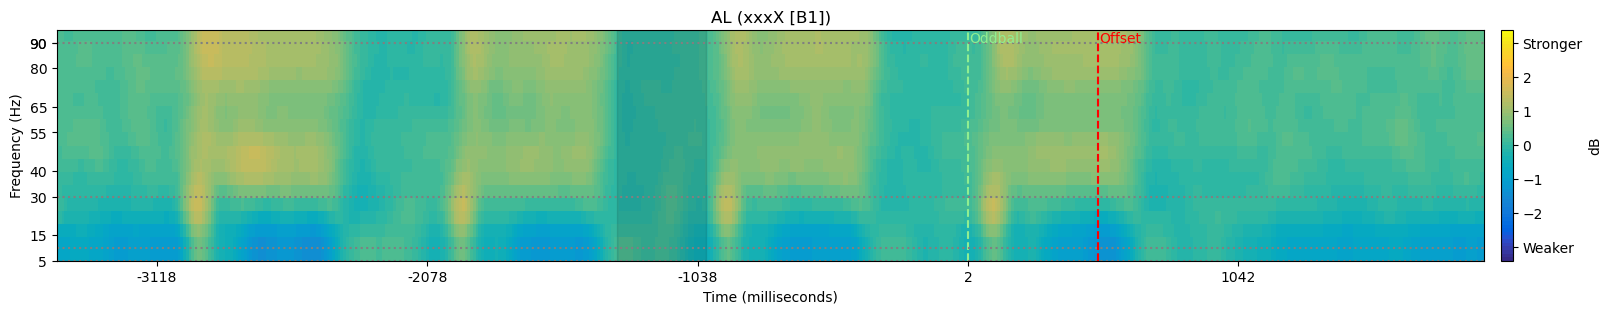

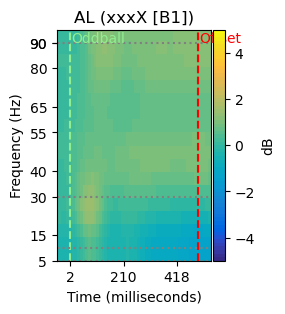

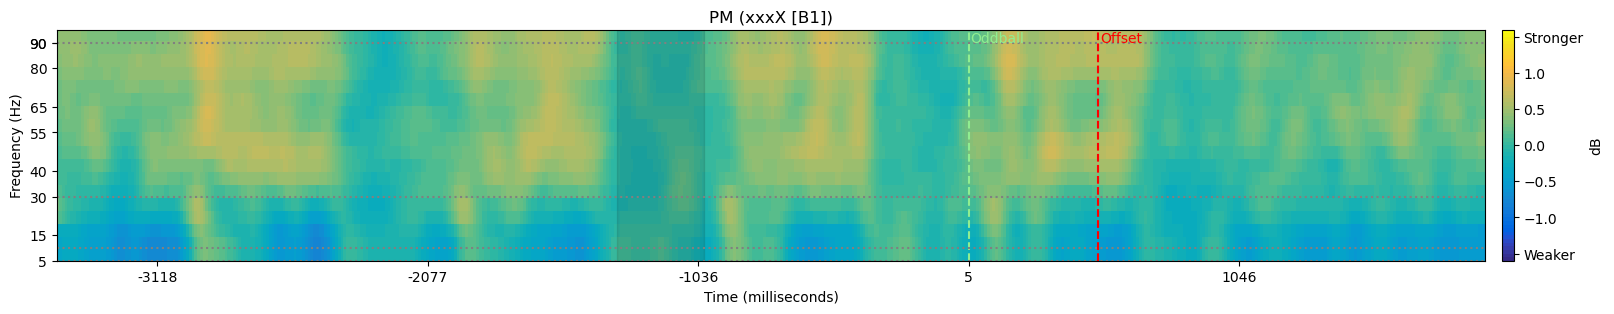

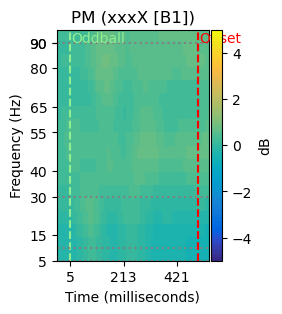

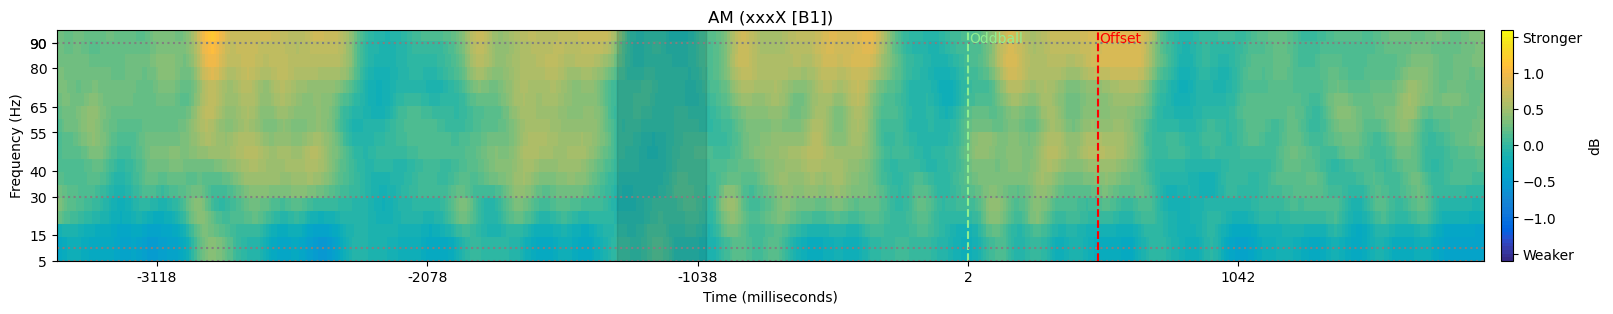

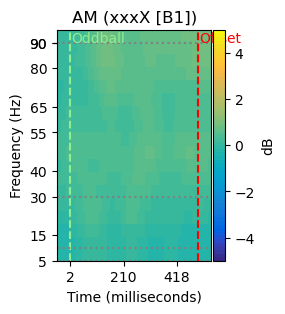

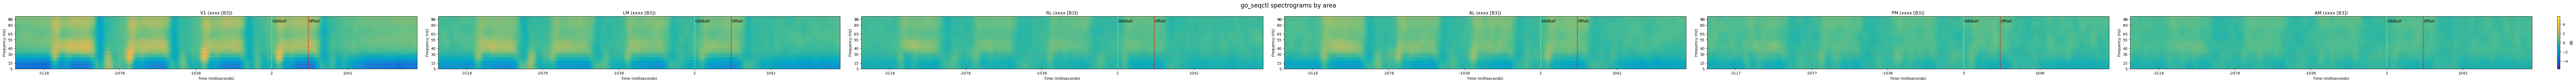

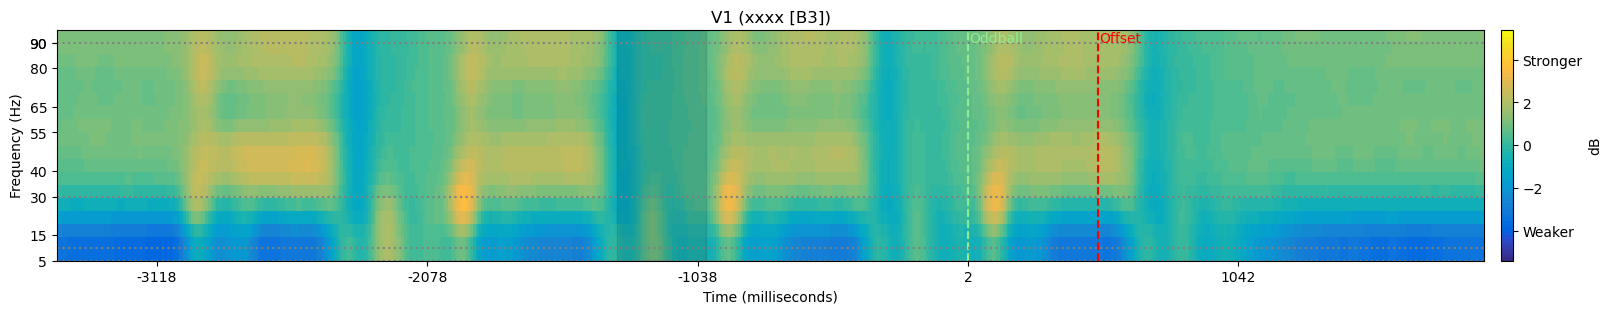

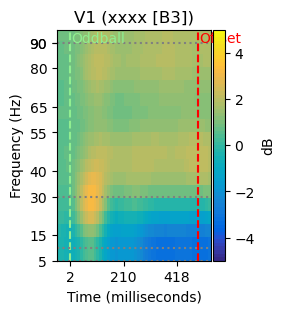

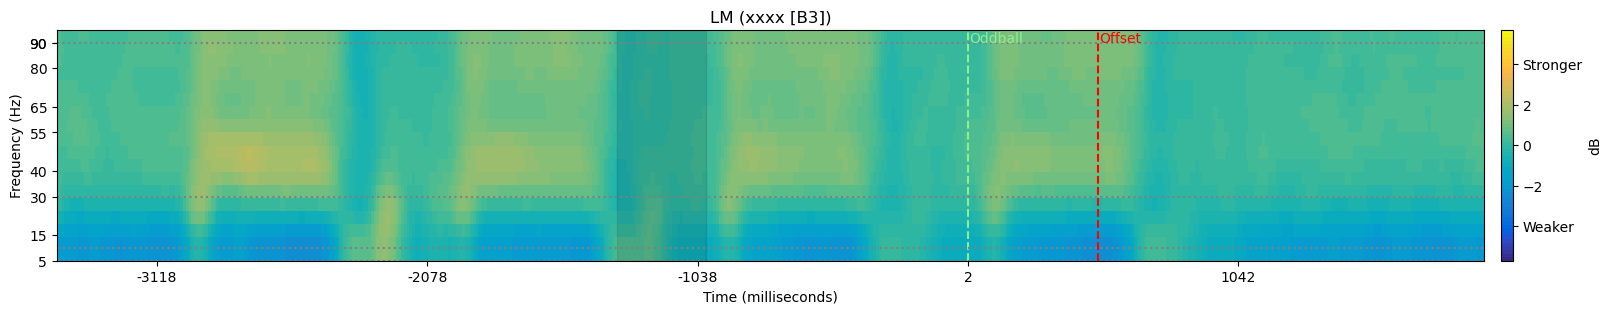

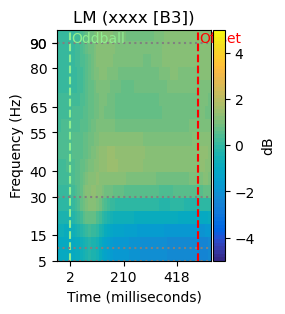

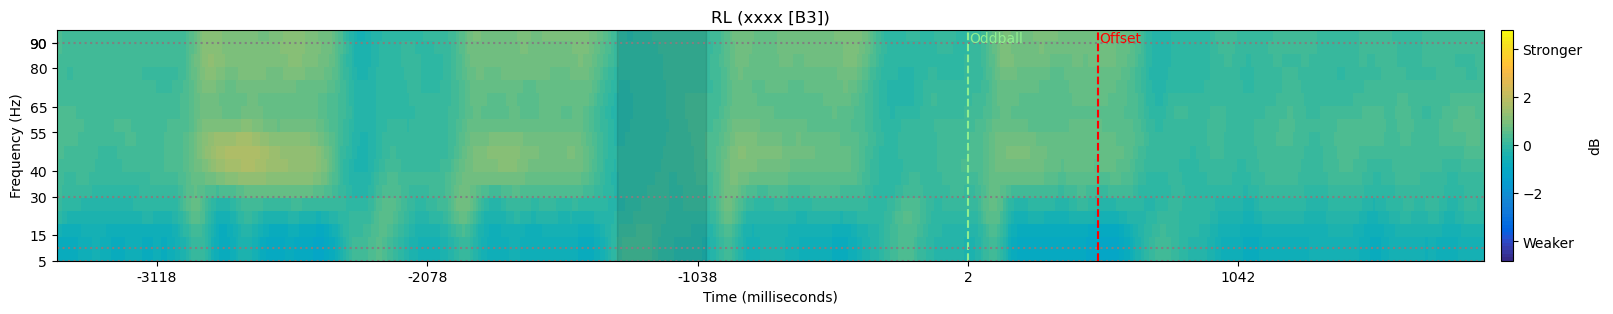

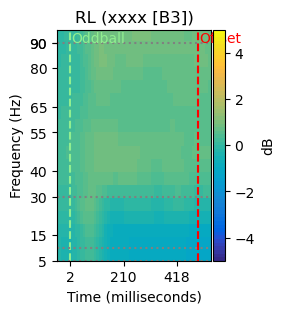

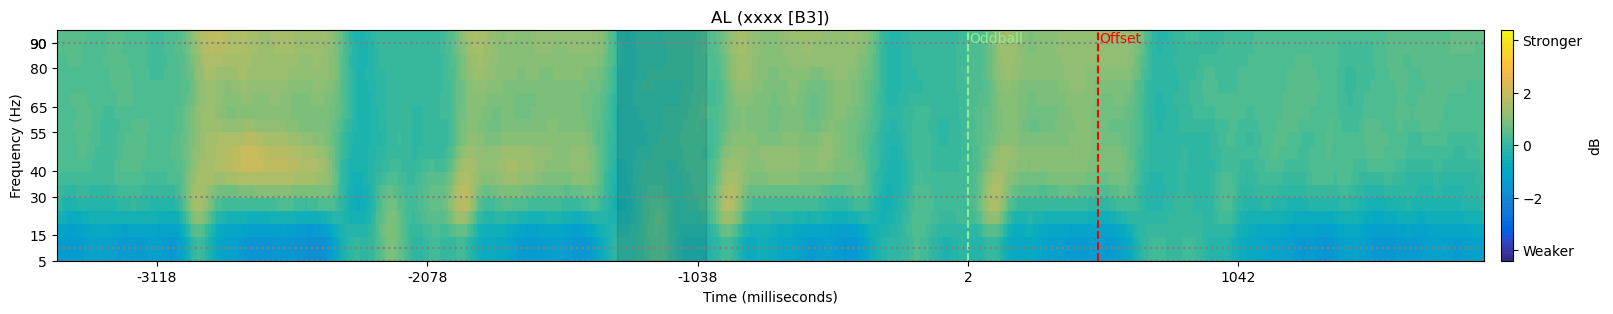

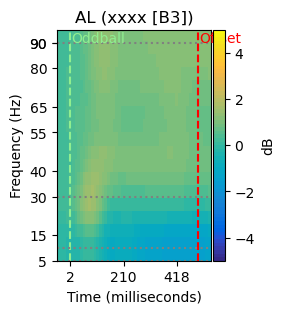

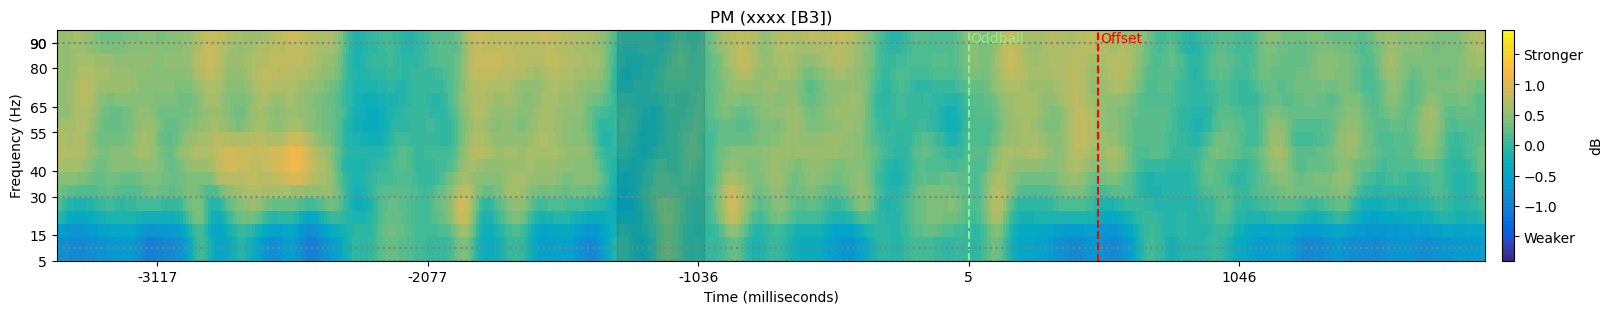

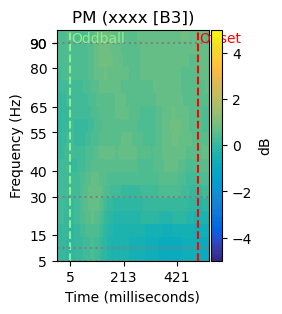

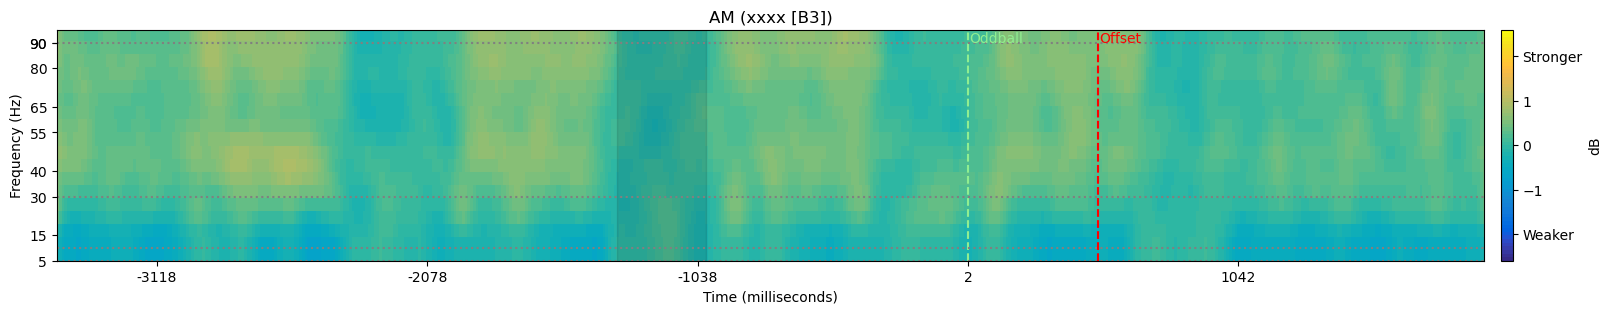

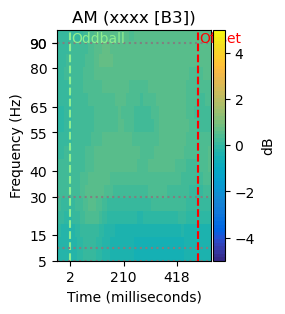

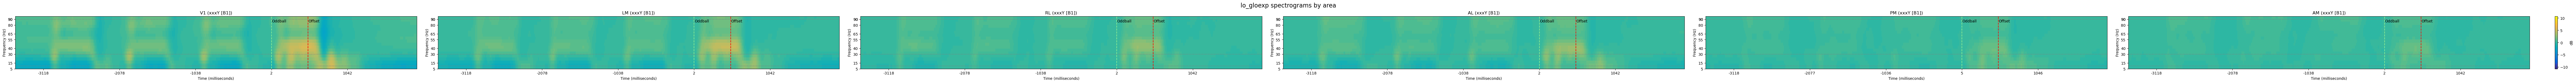

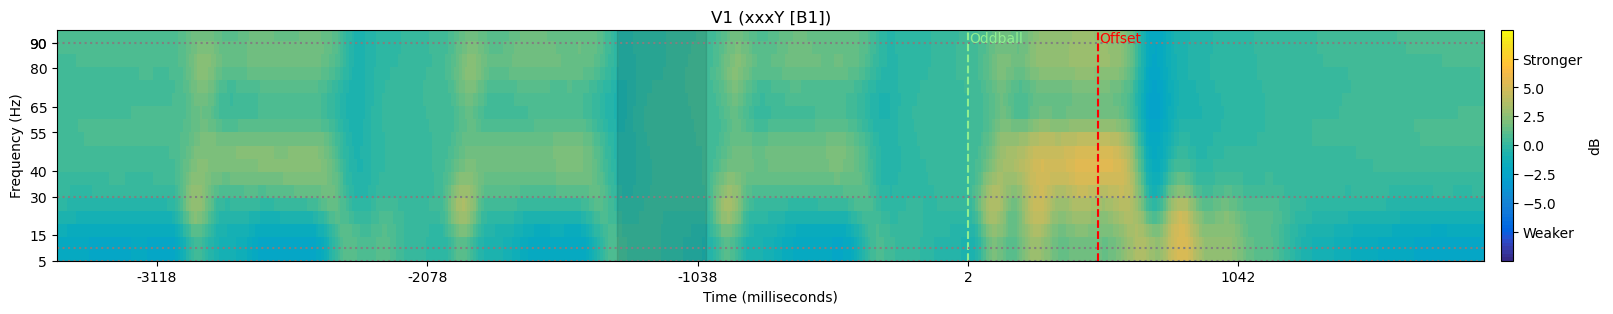

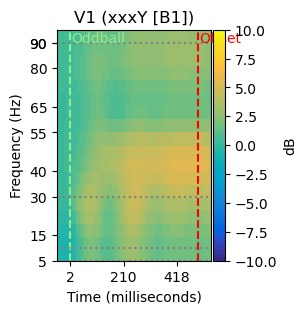

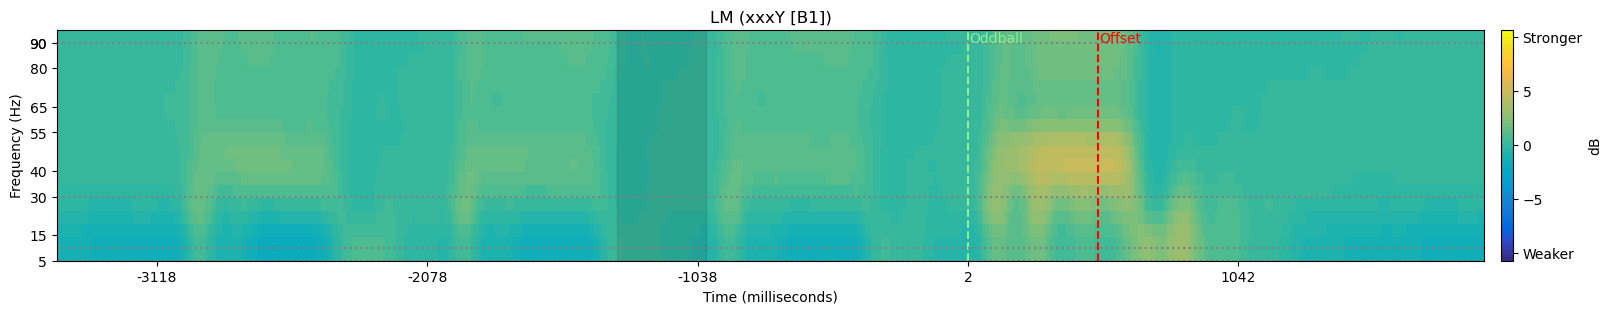

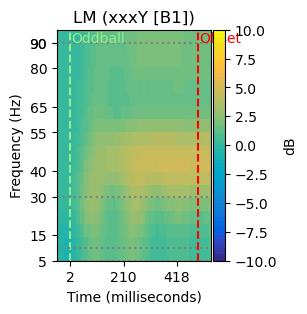

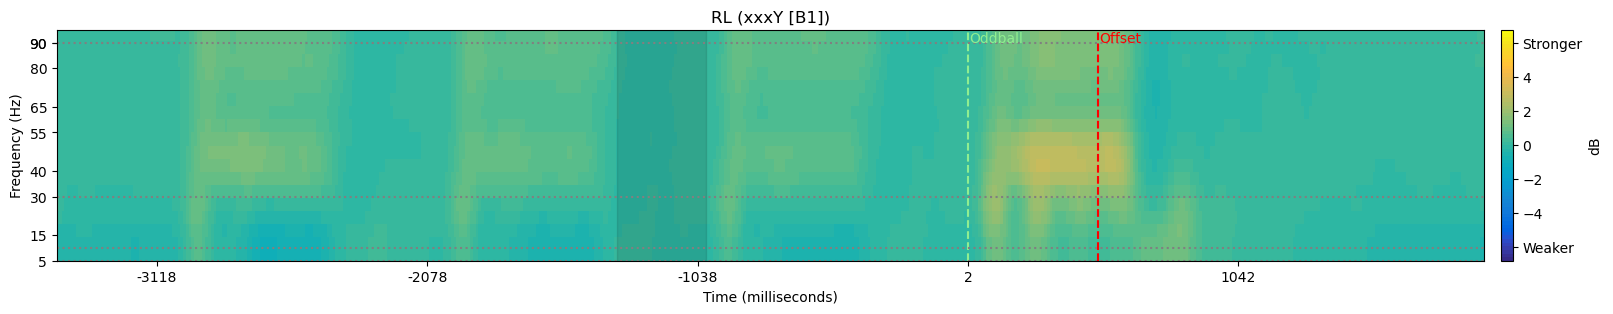

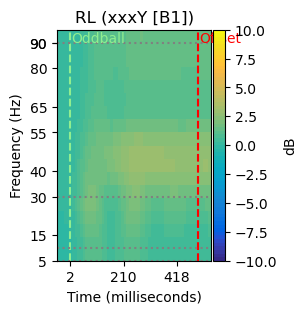

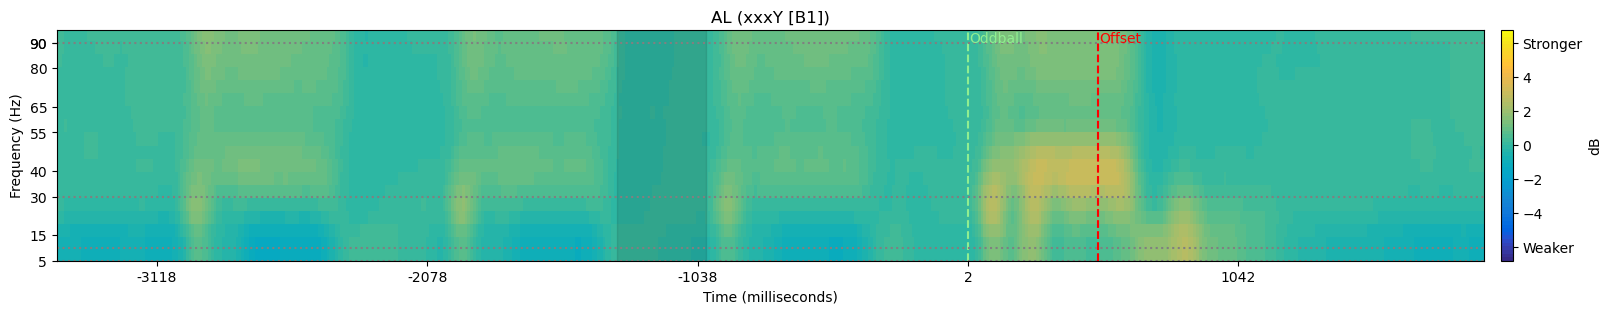

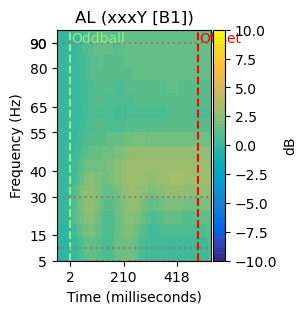

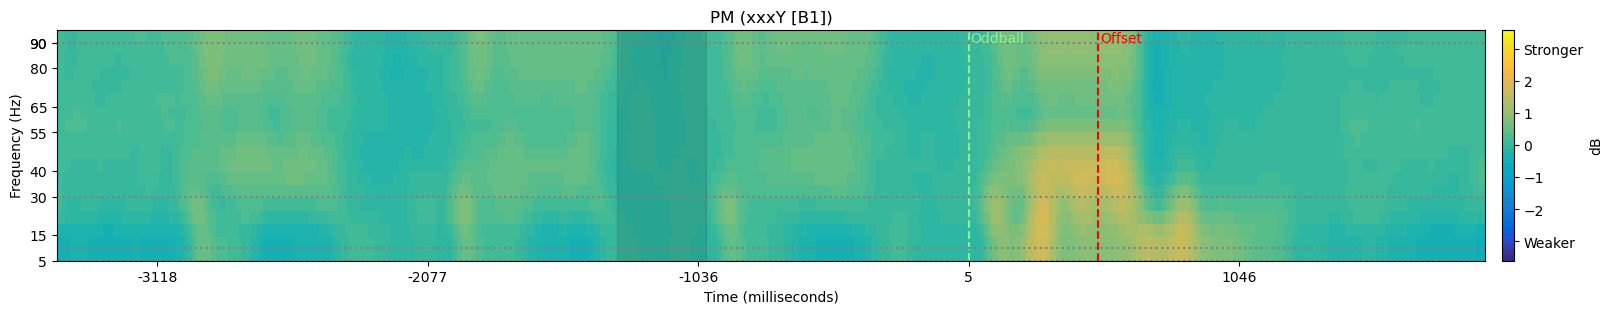

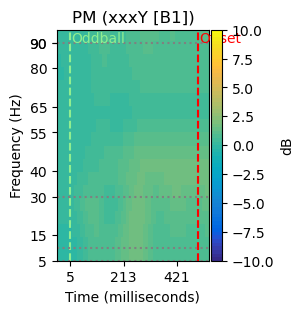

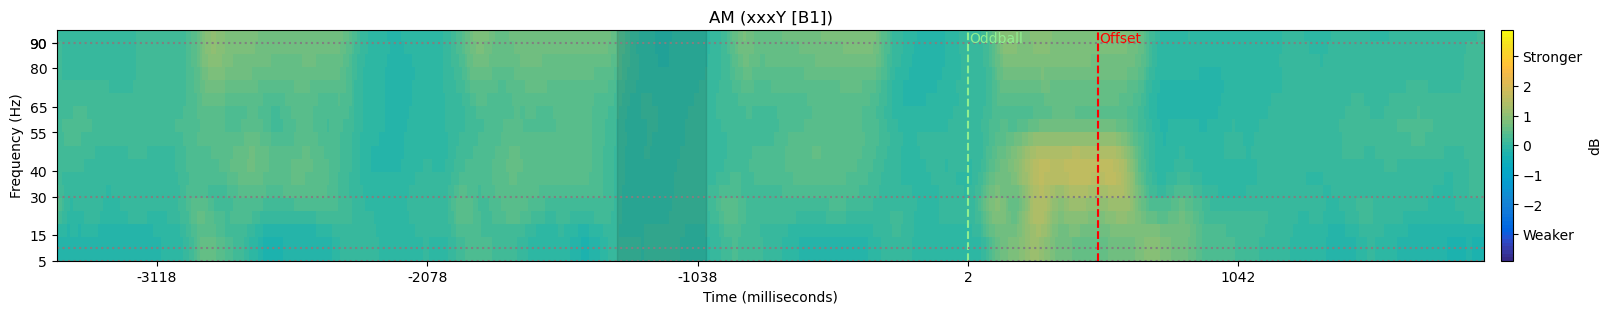

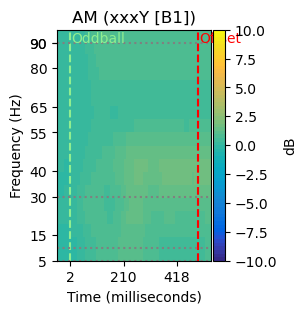

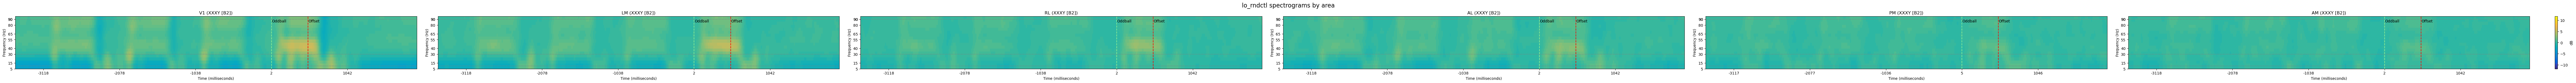

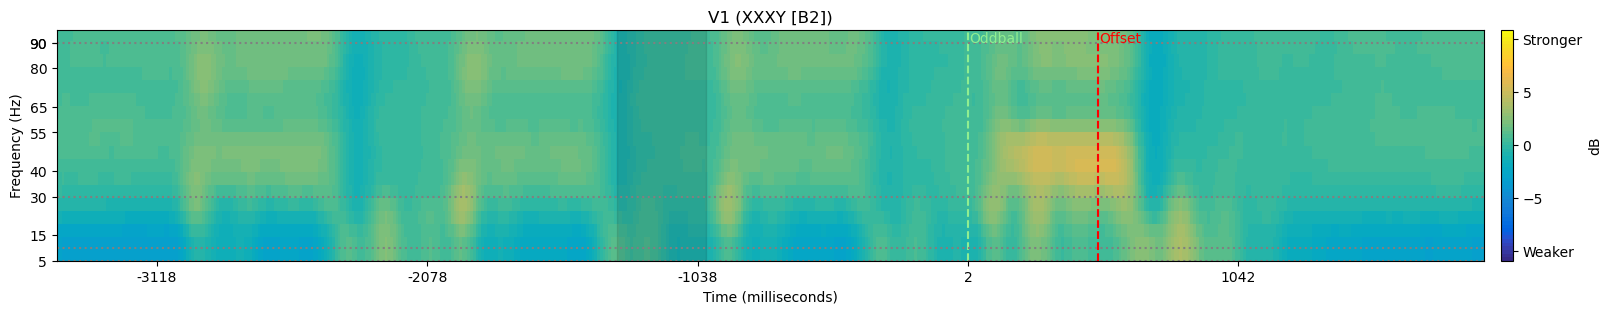

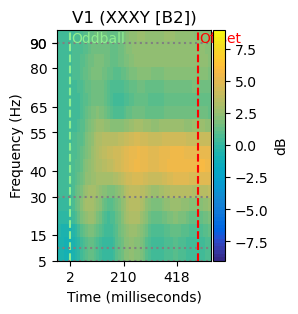

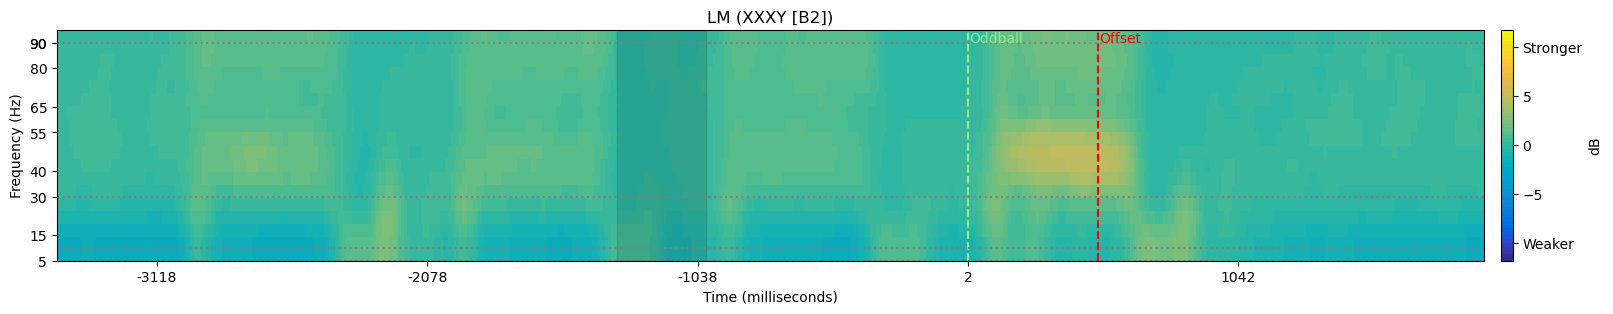

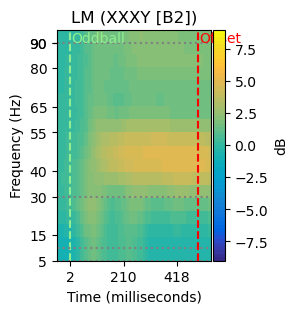

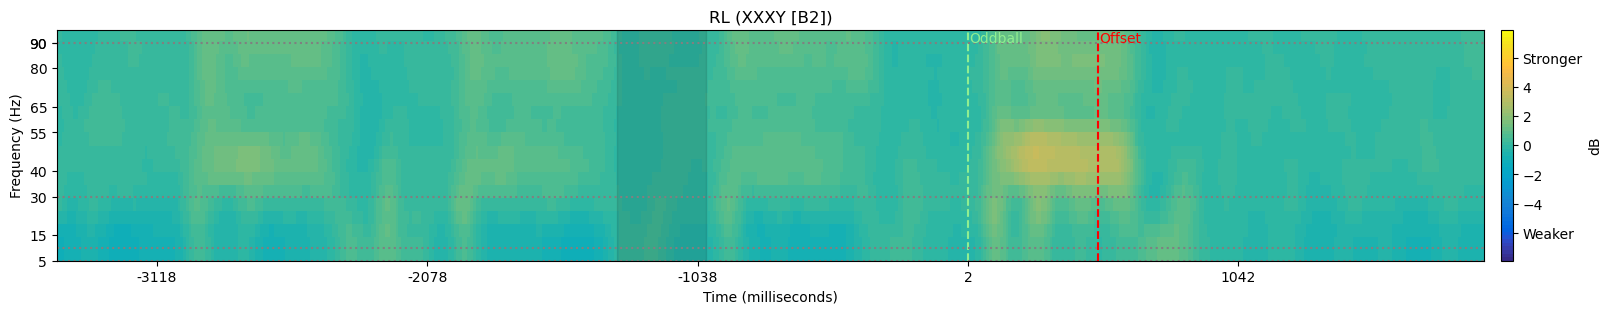

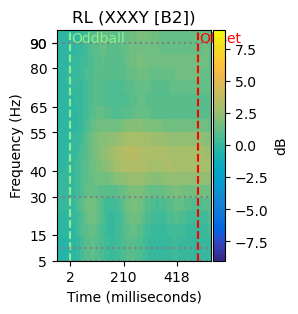

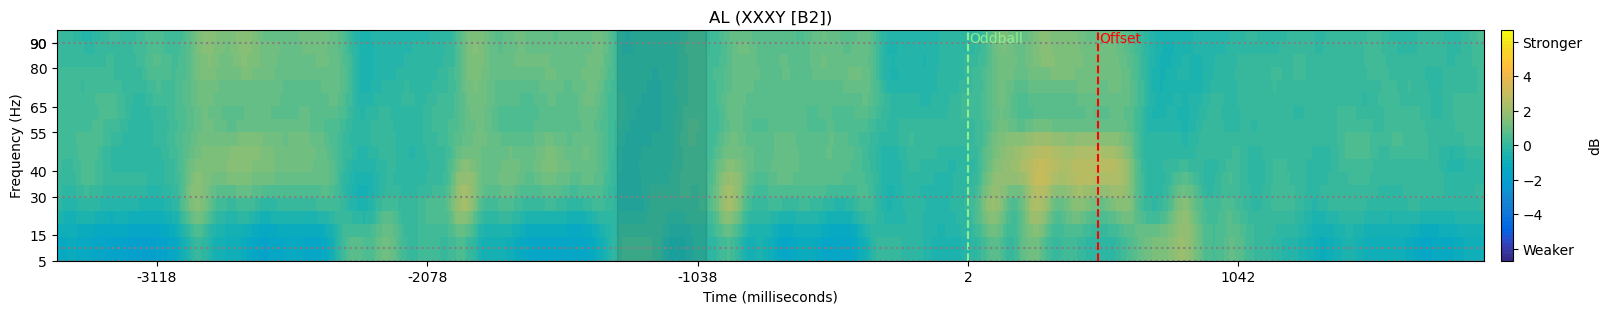

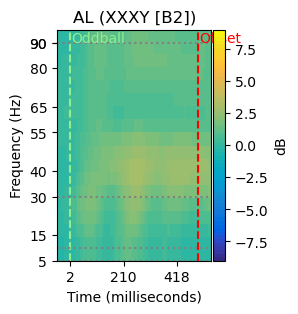

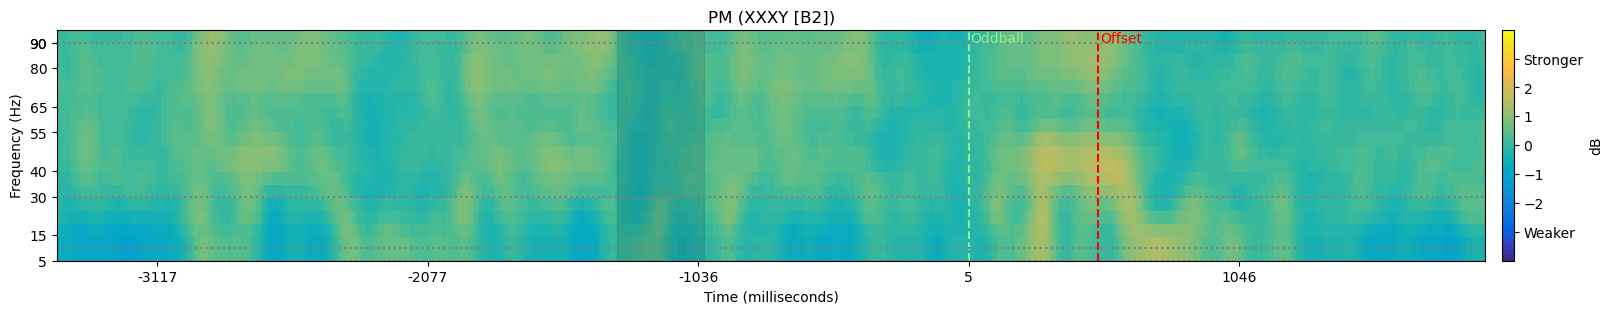

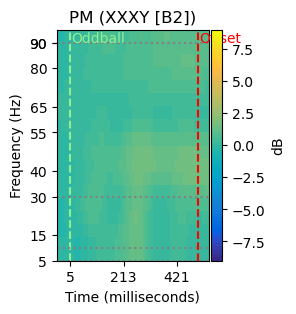

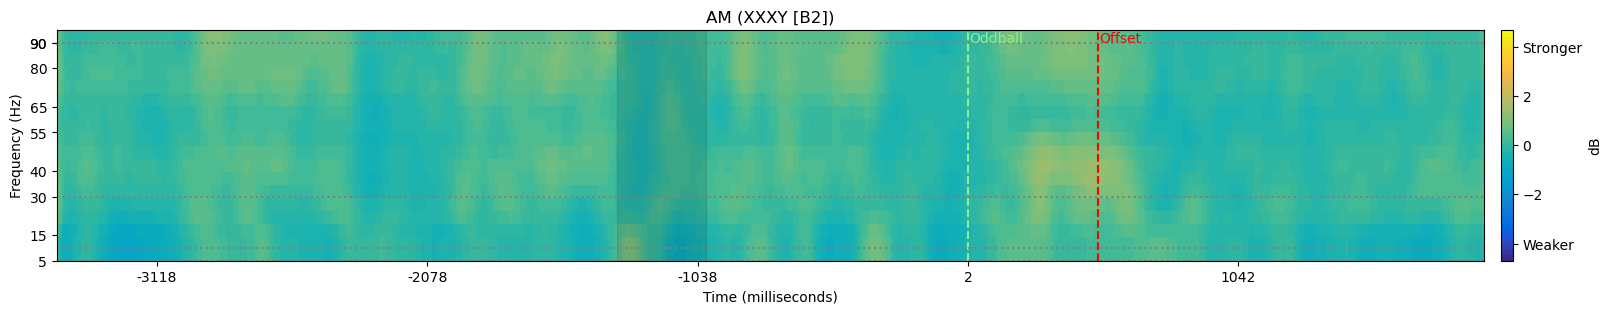

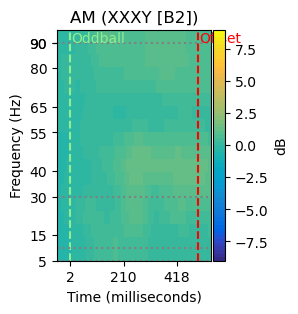

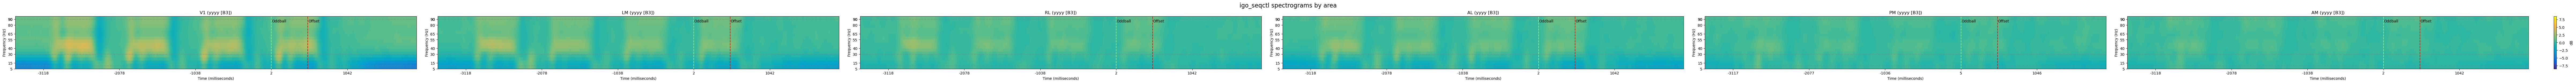

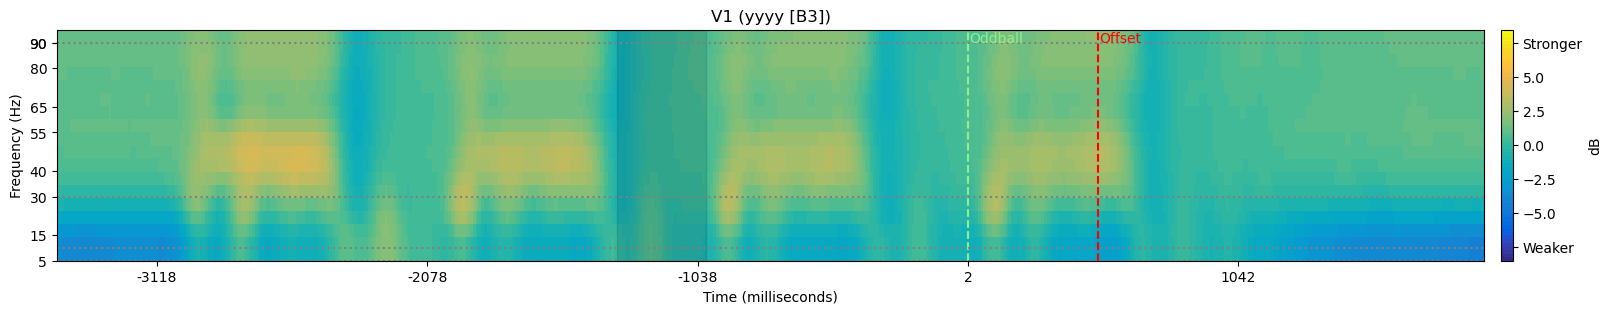

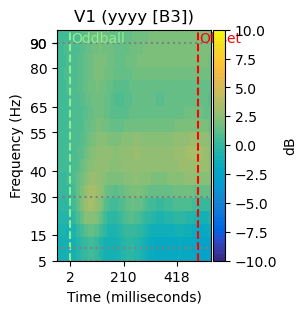

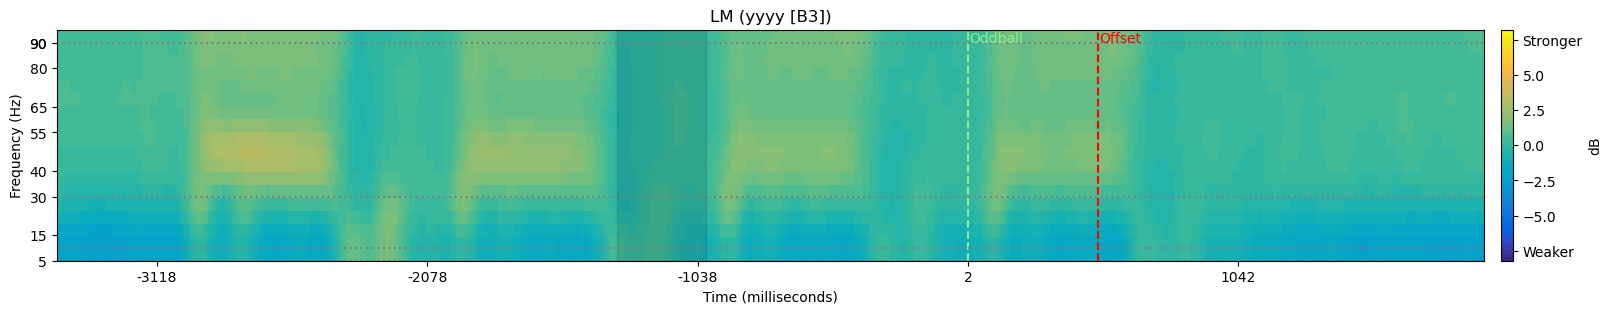

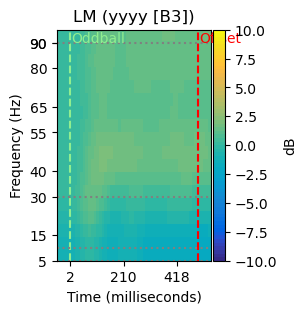

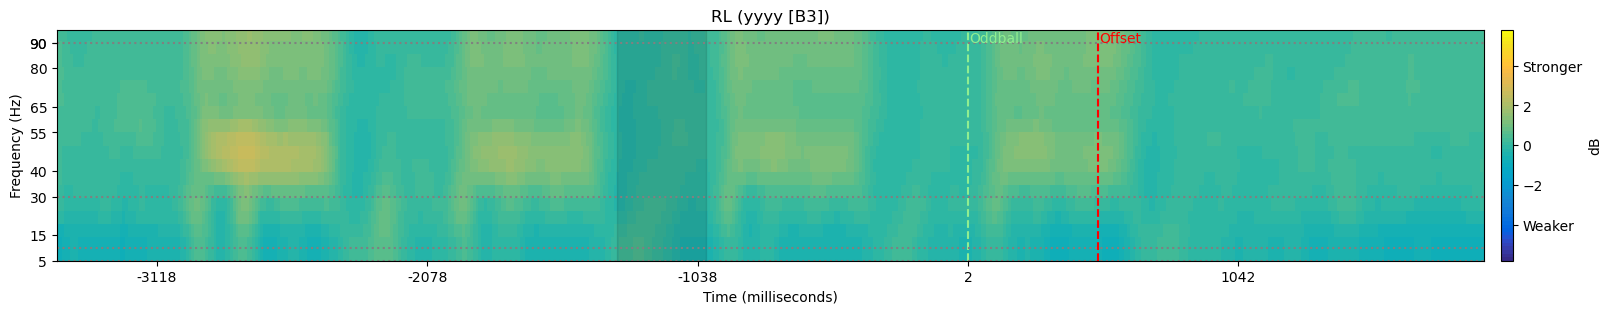

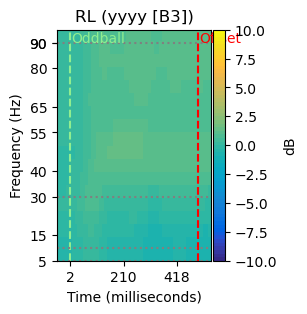

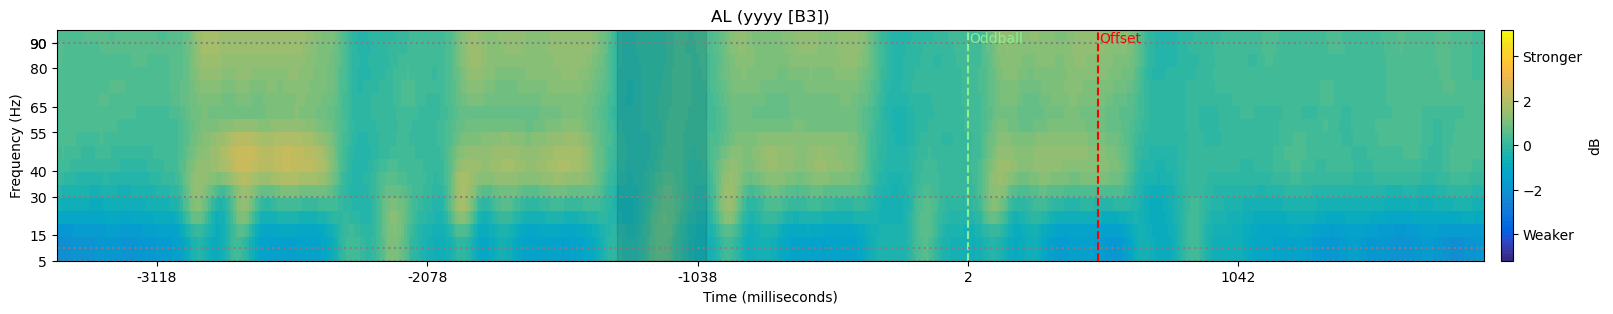

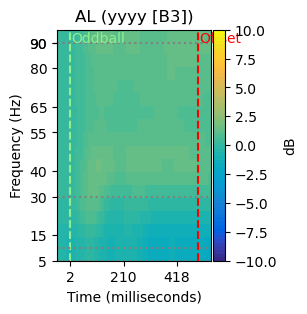

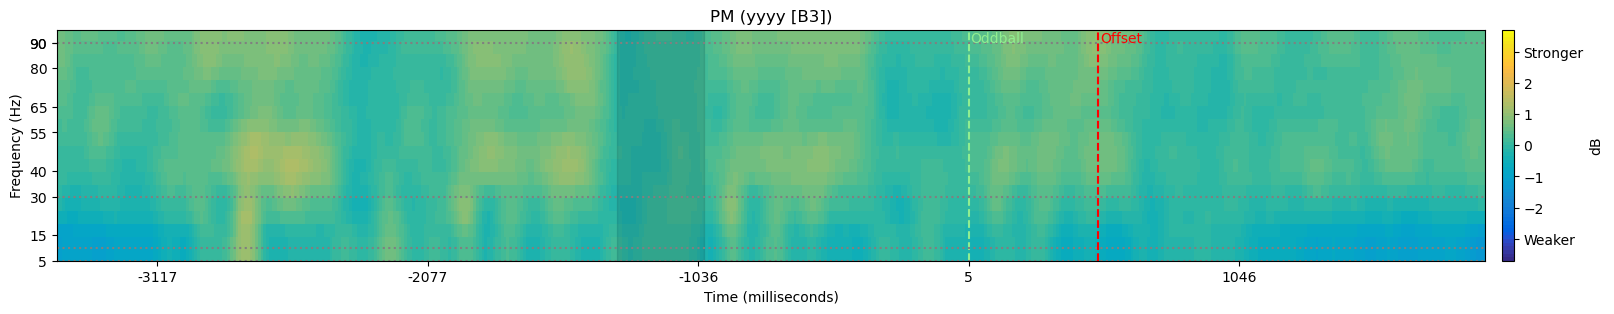

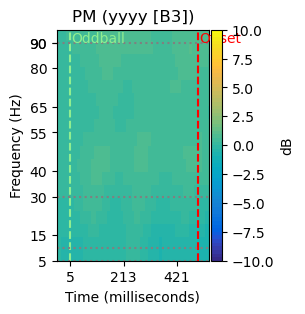

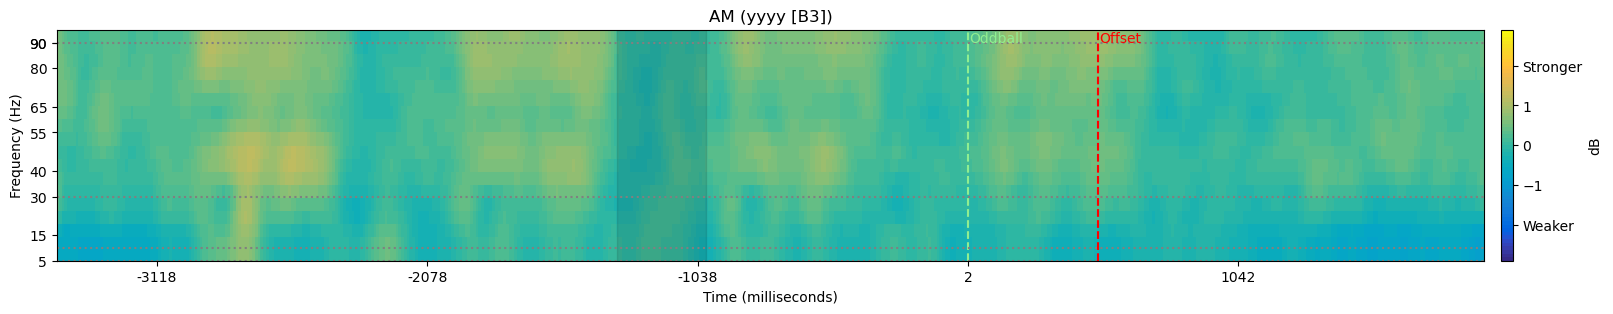

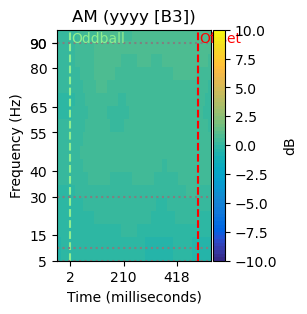

In [14]:
for cond in CONDITIONS:
    cond_stattitle = functools.partial(condition_stattitle, cond)

    tfr_summaries[cond].plot(signals=anatomical_areas, sigtitle=cond_stattitle, title="%s spectrograms by area" % cond,
                          figure="oscillatory_spectrogram_downsample4_%s.png" % cond, width_per_signal=16 * pq.point, **EVENTS)

    for area in anatomical_areas:
        os.makedirs("oscillatory_spectrogram_downsample4_%s/" % cond, exist_ok=True)
        tfr_summaries[cond].signals[area].plot(title=cond_stattitle(area, tfr_summaries[cond].signals[area], layer=None), filename="oscillatory_spectrogram_downsample4_%s/%s.png" % (cond, area),
                                               baseline=(-1.350, -1.010), cbar_ends=("Stronger", "Weaker"), tlabel="Time (milliseconds)", **EVENTS)

        oddball_signal = tfr_summaries[cond].signals[area][ODDBALL_ONSET.magnitude - 0.050:ODDBALL_OFFSET.magnitude + 0.050]
        oddball_signal.plot(title=cond_stattitle(area, tfr_summaries[cond].signals[area], layer=None), tlabel="Time (milliseconds)",
                            vmin=-CONDITION_VLIMS[cond], vmax=CONDITION_VLIMS[cond],
                            filename="oscillatory_spectrogram_downsample4_%s/%s_oddball.png" % (cond, area), **EVENTS)